In [1]:
# Imports and setup
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Plot settings
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 11

In [2]:
log_dir = Path("logs/2026-03-04/06-03-15/lightning_logs/version_0")

event_acc = EventAccumulator(str(log_dir))
event_acc.Reload()

tags = event_acc.Tags()
tags

{'images': [],
 'audio': [],
 'histograms': [],
 'scalars': ['hp_metric',
  'lr-Adam',
  'train/loss',
  'epoch',
  'val/loss',
  'val/CER',
  'val/IER',
  'val/DER',
  'val/SER',
  'train/CER',
  'train/IER',
  'train/DER',
  'train/SER',
  'test/loss',
  'test/CER',
  'test/IER',
  'test/DER',
  'test/SER'],
 'distributions': [],
 'tensors': [],
 'graph': False,
 'meta_graph': False,
 'run_metadata': []}

In [3]:
# Helper function to convert TensorBoard scalars into a DataFrame
def scalar_to_df(event_acc, tag):
    events = event_acc.Scalars(tag)
    return pd.DataFrame({
        "step": [e.step for e in events],
        "value": [e.value for e in events],
        "wall_time": [e.wall_time for e in events],
    })

In [4]:
# Load the main metrics
available_scalars = tags.get("scalars", [])
print("Available scalar metrics:")
for s in available_scalars:
    print("-", s)

Available scalar metrics:
- hp_metric
- lr-Adam
- train/loss
- epoch
- val/loss
- val/CER
- val/IER
- val/DER
- val/SER
- train/CER
- train/IER
- train/DER
- train/SER
- test/loss
- test/CER
- test/IER
- test/DER
- test/SER


In [5]:
# Load the important metrics
val_cer_df = scalar_to_df(event_acc, "val/CER")
val_loss_df = scalar_to_df(event_acc, "val/loss")

# Try both possible training loss names, depending on how Lightning logged them
train_loss_tag = None
for candidate in ["train/loss", "train/loss_epoch"]:
    if candidate in available_scalars:
        train_loss_tag = candidate
        break

if train_loss_tag is not None:
    train_loss_df = scalar_to_df(event_acc, train_loss_tag)
else:
    train_loss_df = None
    print("No train loss scalar found.")

In [6]:
# Add an epoch axis
val_cer_df["epoch_idx"] = range(len(val_cer_df))
val_loss_df["epoch_idx"] = range(len(val_loss_df))

if train_loss_df is not None:
    train_loss_df["point_idx"] = range(len(train_loss_df))

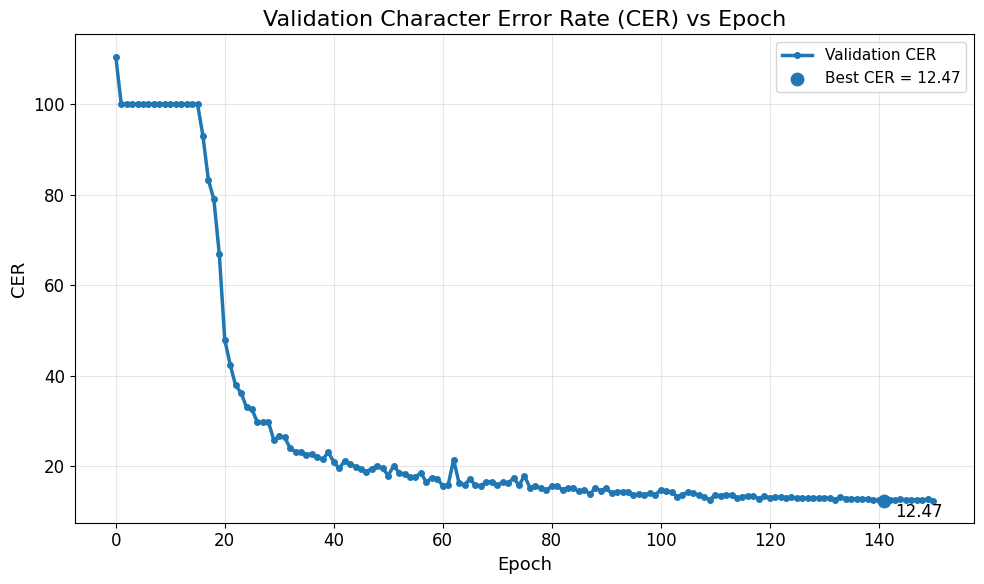

In [7]:
# Validation CER over epochs
fig, ax = plt.subplots()

ax.plot(
    val_cer_df["epoch_idx"],
    val_cer_df["value"],
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Validation CER"
)

best_idx = val_cer_df["value"].idxmin()
best_epoch = val_cer_df.loc[best_idx, "epoch_idx"]
best_cer = val_cer_df.loc[best_idx, "value"]

ax.scatter(best_epoch, best_cer, s=80, zorder=3, label=f"Best CER = {best_cer:.2f}")
ax.annotate(
    f"{best_cer:.2f}",
    (best_epoch, best_cer),
    textcoords="offset points",
    xytext=(8, -12)
)

ax.set_title("Validation Character Error Rate (CER) vs Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("CER")
ax.legend()
plt.tight_layout()
plt.show()

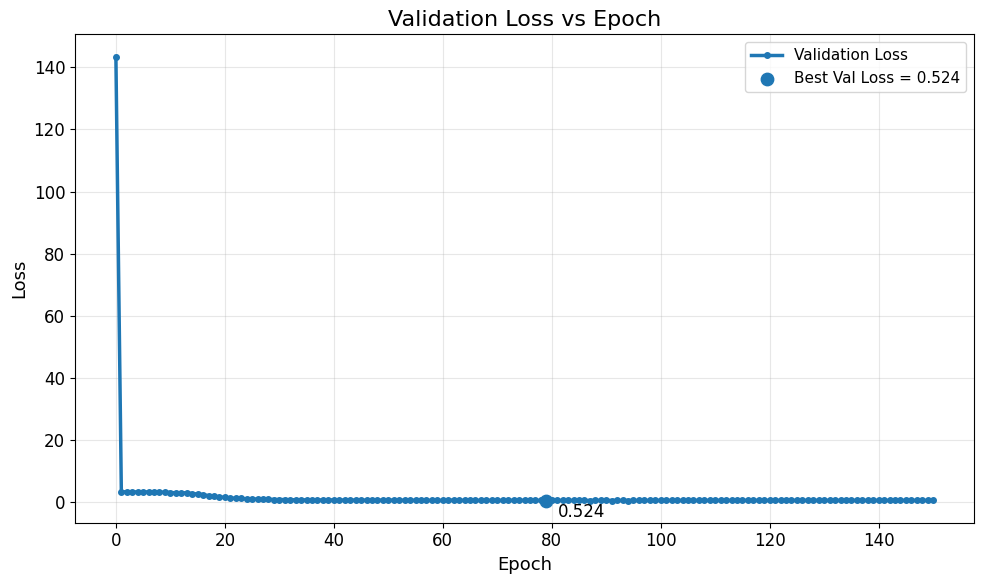

In [8]:
# Validation loss over epochs
fig, ax = plt.subplots()

ax.plot(
    val_loss_df["epoch_idx"],
    val_loss_df["value"],
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Validation Loss"
)

best_idx = val_loss_df["value"].idxmin()
best_epoch = val_loss_df.loc[best_idx, "epoch_idx"]
best_loss = val_loss_df.loc[best_idx, "value"]

ax.scatter(best_epoch, best_loss, s=80, zorder=3, label=f"Best Val Loss = {best_loss:.3f}")
ax.annotate(
    f"{best_loss:.3f}",
    (best_epoch, best_loss),
    textcoords="offset points",
    xytext=(8, -12)
)

ax.set_title("Validation Loss vs Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

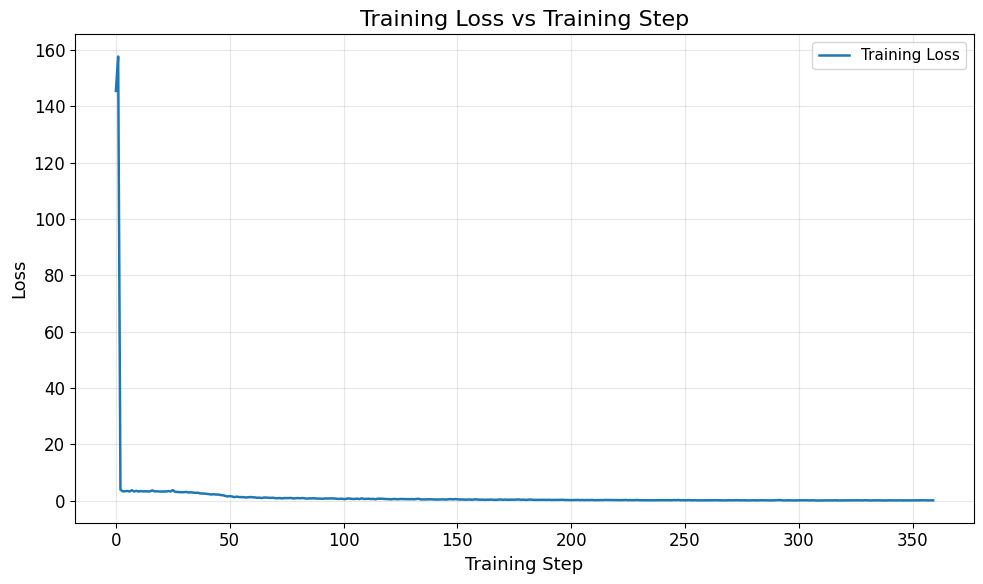

In [9]:
# Training loss over training steps
if train_loss_df is not None:
    fig, ax = plt.subplots()

    ax.plot(
        train_loss_df["point_idx"],
        train_loss_df["value"],
        linewidth=1.8,
        label="Training Loss"
    )

    ax.set_title("Training Loss vs Training Step")
    ax.set_xlabel("Training Step")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Training loss not found in TensorBoard scalars.")

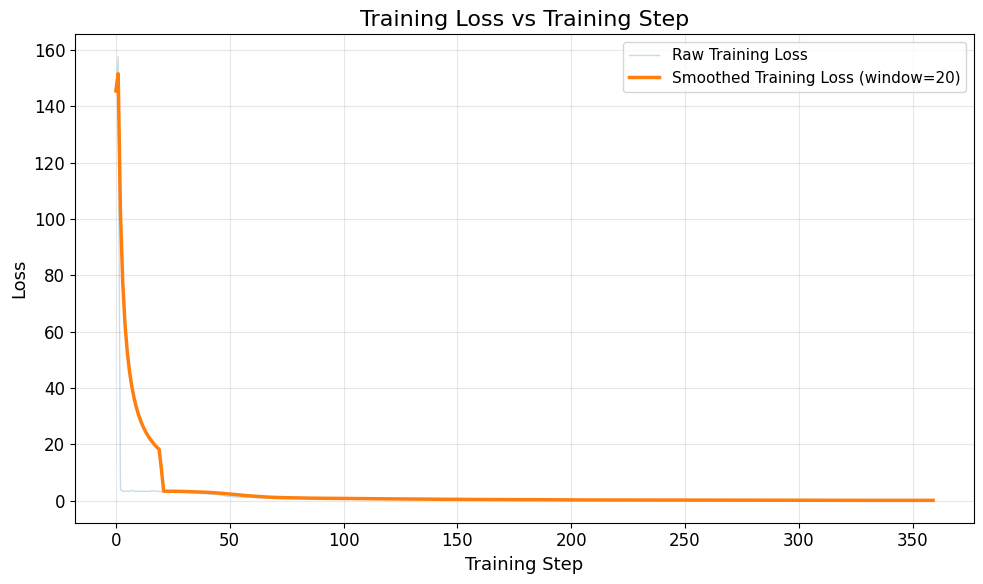

In [10]:
# Smoothed training loss plot for cleaner visualization
if train_loss_df is not None:
    smooth_window = 20
    train_loss_df["smoothed"] = train_loss_df["value"].rolling(smooth_window, min_periods=1).mean()

    fig, ax = plt.subplots()

    ax.plot(
        train_loss_df["point_idx"],
        train_loss_df["value"],
        alpha=0.25,
        linewidth=1,
        label="Raw Training Loss"
    )
    ax.plot(
        train_loss_df["point_idx"],
        train_loss_df["smoothed"],
        linewidth=2.5,
        label=f"Smoothed Training Loss (window={smooth_window})"
    )

    ax.set_title("Training Loss vs Training Step")
    ax.set_xlabel("Training Step")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [11]:
# Summary table
summary_df = pd.DataFrame({
    "Metric": [
        "Best Validation CER",
        "Final Validation Loss",
        "Test CER",
        "Test Loss",
        "Model Parameters"
    ],
    "Value": [
        round(val_cer_df["value"].min(), 3),
        round(val_loss_df["value"].iloc[-1], 3),
        17.951,   # from your test output
        0.719,    # from your test output
        "3.5M"
    ]
})

summary_df

,Metric,Value
0,Best Validation CER,12.472
1,Final Validation Loss,0.553
2,Test CER,17.951
3,Test Loss,0.719
4,Model Parameters,3.5M


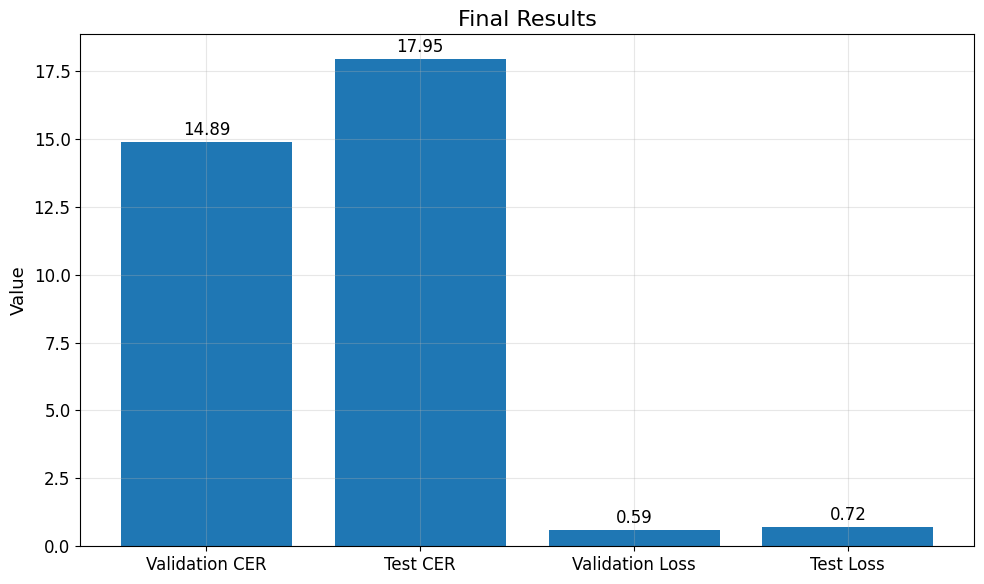

In [12]:
final_results = pd.DataFrame({
    "Metric": ["Validation CER", "Test CER", "Validation Loss", "Test Loss"],
    "Value": [14.887, 17.951, 0.592, 0.719]
})

fig, ax = plt.subplots()

bars = ax.bar(final_results["Metric"], final_results["Value"])

ax.set_title("Final Results")
ax.set_ylabel("Value")

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [14]:

!ls logs/final_training_run/lightning_logs/version_0

events.out.tfevents.1773256626.dl-wm1  events.out.tfevents.1773273031.dl-wm1
events.out.tfevents.1773273028.dl-wm1  hparams.yaml


In [15]:
!pwd

/home/neiljohnson/project/semg-keystroke-decoding
